In [3]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
import netCDF4 as nc
import pandas as pd
from pathlib import Path

from iwave import Iwave

ROOT = Path.cwd()
sys.path.append(str(ROOT.parent))
from common.utils import median_filter_iwave

Definition of an IWaVE instance with video parameters

In [4]:
# video parameters
resolution = 0.034 # resolution in cm/pxl
downsample = 4 # downsampling ratio
fps = 30 # frame rate (frames per second)
vid_duration = 29 # whole video duration (seconds)
segment_duration = 10 # sub-segment duration (seconds)
p_weight = 1.5 # penalty weight (reduces overshooting)
win_size = (48,48) # size of a window (pxl)
filename = "ex1L_vid" # video ID
videopath = ROOT / "data" / "raw_video" / f"{filename}.mp4" # video path
savepath = ROOT / "results" # results folder
savepath.mkdir(parents=True, exist_ok=True) 

In [5]:
iw = Iwave(
        resolution=resolution*downsample,
        window_size=win_size,  # size of interrogation windows over which velocities are estimated
        overlap=(-48,-48), # (win_size[0] / 2, win_size[1] / 2),  # overlap in space (y, x) used to select windows from images or frames
        time_size=int(segment_duration*fps),  # amount of frames in time used for one spectral analysis
        time_overlap=int(segment_duration*fps/2),  # amount of overlap in frames, used to establish time slices. Selecting half of
            # time_size implies that you use a 50% overlap in time between frame sets.
        fps=fps,
        smax = 2.0,
        window_chunk_size = 50
    )

In [6]:
# read video
iw.read_video(videopath, start_frame=0, end_frame=int(vid_duration*fps), stride = downsample) #

100%|██████████| 870/870 [01:13<00:00, 11.85it/s]


In [7]:
print(iw)

# show the shape of the read images
print(f"Shape of the available images is {iw.imgs.shape}")

# show the shape of the manipulated windows
print(f"Shape of the windows set is {iw.windows.shape}")


Resolution [m]: 0.136
Window size (y, x): (48, 48)
Overlap (y, x): (-48, -48)
Size of time slices: 300
Overlap in time slices: 150
Number of images: 870
Frames per second: 29.97

Shape of the available images is (870, 540, 960)
Shape of the windows set is (60, 870, 48, 48)


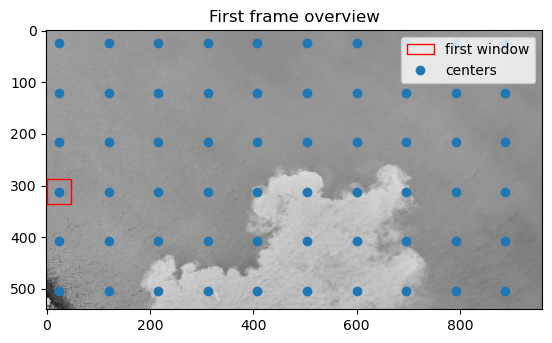

In [8]:
# plot image with measurement grid
ax = plt.axes()

# plot the first image with a patch at the first window and centers of rest in the first axes instance
win = np.int_(iw.windows.shape[0]/2)
xi, yi = np.meshgrid(iw.x, iw.y)
x_patch = np.int_(xi.flatten()[win]) - np.int_(win_size[0] / 2)
y_patch = np.int_(yi.flatten()[win]) - np.int_(win_size[1] / 2)
first_window = patches.Rectangle((x_patch, y_patch), win_size[0], win_size[1], linewidth=1, edgecolor='r', facecolor='none', label="first window")

ax.imshow(iw.imgs[0], cmap="Greys_r")
ax.add_patch(first_window)
ax.plot(xi.flatten(), yi.flatten(), "o", label="centers")
ax.legend()
ax.set_title("First frame overview")

plt.show()

VELOCITY CALCULATION

In [9]:
# calculate velocities
iw.velocimetry(
    alpha=1.00,  # alpha represents the depth-averaged velocity over surface velocity [-]
    depth=100,
    penalty_weight = p_weight
)

Optimization in 2 steps with spectrum downsampling factor [2, 1]


Optimizing windows: 100%|██████████| 60/60 [04:33<00:00,  4.56s/it] 


RESULTS VISUALISATION

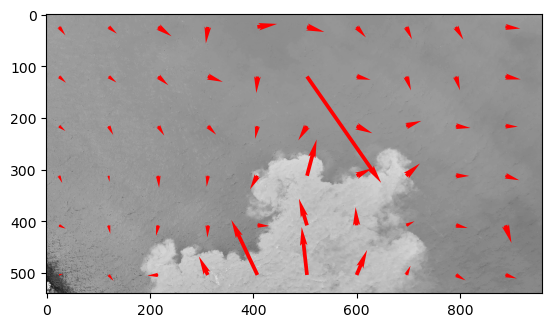

In [10]:
ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

# add velocity vectors
iw.plot_velocimetry(ax=ax, color="r", scale=3, headwidth=2, linewidth=2)  # you can add kwargs that belong to matplotlib.pyploy.quiver
plt.show()

EXTRACT RESULTS

In [11]:
ux, uy, d, q = iw.vx, iw.vy, iw.d, iw.quality
u = np.sqrt(ux**2 + uy**2)

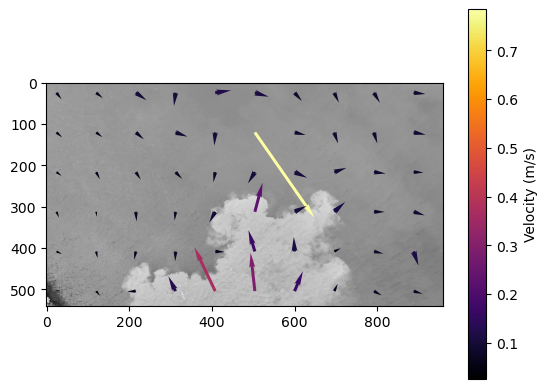

In [12]:
# nicer visualisation

ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

quiv = ax.quiver(
    xi, yi, ux, -uy,
    u,                          
    angles="xy", scale=3, headwidth=2, linewidth=2,
    cmap="inferno"              
)

cbar = plt.colorbar(quiv, ax=ax)
cbar.set_label("Velocity (m/s)")

ax.set_aspect("equal")
plt.show()

SAVE RESULTS AS NC / csv

In [13]:
# Save results to netCDF file
with nc.Dataset(savepath / f"{filename}_results_noGCPs.nc", 'w', format='NETCDF4') as ds:
    ds.createDimension('x', xi.shape[1])
    ds.createDimension('y', xi.shape[0])

    # pixel coordinates
    xi_var = ds.createVariable('xi', 'f4', ('y', 'x'))
    yi_var = ds.createVariable('yi', 'f4', ('y', 'x'))
    
    xi_var[:, :] = xi
    yi_var[:, :] = yi

    # velocities and quality
    vx_var = ds.createVariable('vx', 'f4', ('y', 'x'))
    vy_var = ds.createVariable('vy', 'f4', ('y', 'x'))
    q_var = ds.createVariable('q', 'f4', ('y', 'x'))
    
    vx_var[:, :] = ux
    vy_var[:, :] = uy
    q_var[:, :] = q

In [14]:
# Save results to csv file

xi_flat = xi.flatten()
yi_flat = yi.flatten()
vx_flat = ux.flatten()
vy_flat = uy.flatten()
q_flat = q.flatten()


# without georeferencing
df = pd.DataFrame({'x': xi_flat, 'y': yi_flat, 'vx': vx_flat, 'vy': vy_flat, 'q': q_flat})

df.to_csv(savepath / f"{filename}_results_noGCPs.csv", index=False)

SPECTRA

windows: [34 23 18 30]


c:\Users\gdolc\miniforge3\envs\iwave-training\Lib\site-packages\iwave\io.py:251: RuntimeWarning: divide by zero encountered in log
  imvals = np.log(imvals)


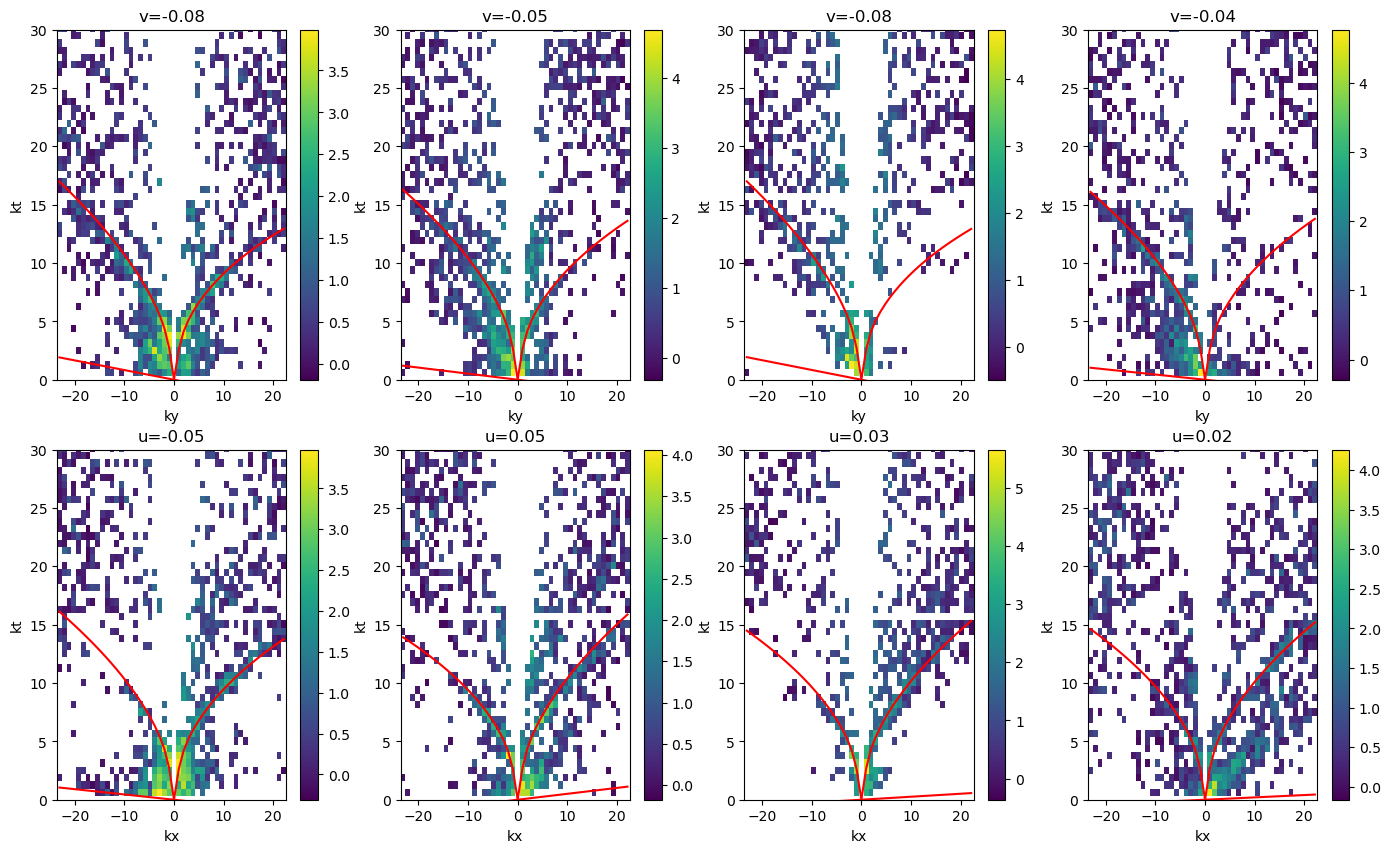

In [15]:
# pick 4 random windows
w_indices = np.random.randint(0, iw.windows.shape[0], size=4)

print(f"windows: {w_indices}")
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(17, 10))
axs = axs.flatten()
for i in range(len(w_indices)):
    p1 = iw.plot_spectrum_fitted(window_idx=int(w_indices[i]), dim="x", ax=axs[i])
    axs[i].set_title(f"v={iw.vy.flatten()[w_indices[i]].item():.2f}")
    axs[i].set_ylim([0, 30])
    plt.colorbar(p1, ax=axs[i])
    p2 = iw.plot_spectrum_fitted(window_idx=int(w_indices[i]), dim="y", ax=axs[i+4])
    axs[i+4].set_title(f"u={iw.vx.flatten()[w_indices[i]].item():.2f}")
    axs[i+4].set_ylim([0, 30])
    plt.colorbar(p2, ax=axs[i+4])
    
plt.show()

QUALITY METRIC

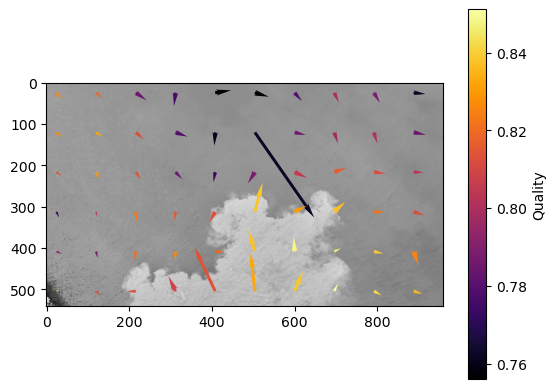

In [16]:
ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

quiv = ax.quiver(
    xi, yi, ux, -uy,
    q,                          
    angles="xy", scale=3, headwidth=2, linewidth=2,
    cmap="inferno"              
)

cbar = plt.colorbar(quiv, ax=ax)
cbar.set_label("Quality")

ax.set_aspect("equal")
plt.show()

C:\Users\gdolc\AppData\Local\Temp\ipykernel_25940\1326569695.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\gdolc\AppData\Local\Temp\ipykernel_25940\1326569695.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
C:\Users\gdolc\AppData\Local\Temp\ipykernel_25940\1326569695.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


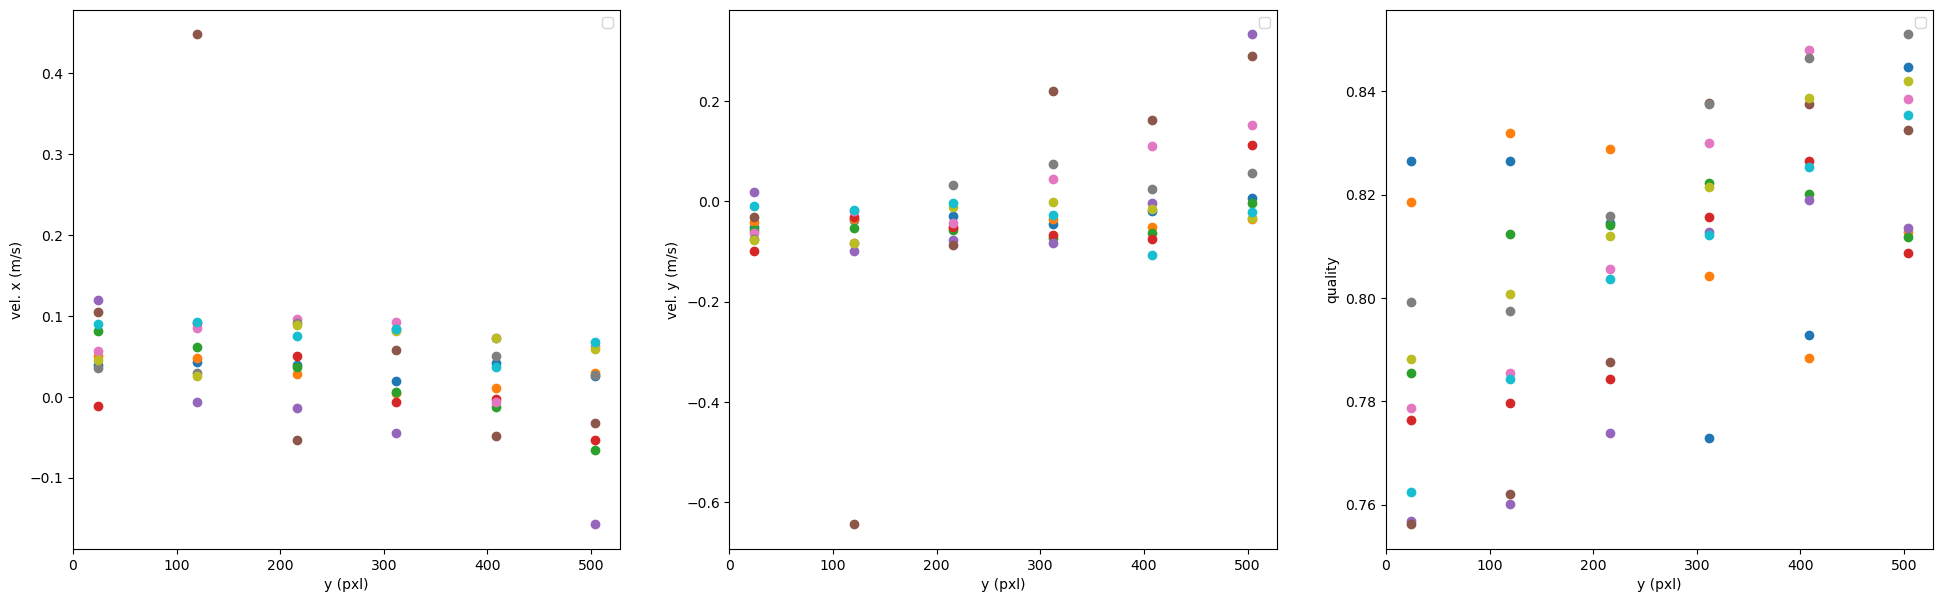

In [17]:
# plot velocity transects (spatial coordinates in pixels)

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))

for j in range(ux.shape[1]):
    axs[0].plot(yi[:,j].flatten(),ux[:,j].flatten(), 'o')
axs[0].set_xlabel('y (pxl)')
axs[0].set_ylabel('vel. x (m/s)')
axs[0].legend()

for j in range(uy.shape[1]):
    axs[1].plot(yi[:,j].flatten(),uy[:,j].flatten(), 'o')
axs[1].set_xlabel('y (pxl)')
axs[1].set_ylabel('vel. y (m/s)')
axs[1].legend()

for j in range(q.shape[1]):
    axs[2].plot(yi[:,j].flatten(),q[:,j].flatten(), 'o')
axs[2].set_xlabel('y (pxl)')
axs[2].set_ylabel('quality')
axs[2].legend()


# Display the plot
plt.show()

FILTERING

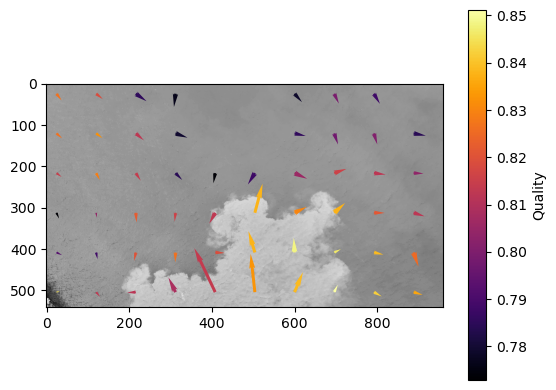

In [18]:
# quality threshold

q_threshold = 0.77

mask = q > q_threshold
ux_masked = np.where(mask, ux, np.nan)
uy_masked = np.where(mask, uy, np.nan)

ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

quiv = ax.quiver(
    xi, yi, ux_masked, -uy_masked,
    q,                          
    angles="xy", scale=3, headwidth=2, linewidth=2,
    cmap="inferno"              
)

cbar = plt.colorbar(quiv, ax=ax)
cbar.set_label("Quality")

ax.set_aspect("equal")
plt.show()

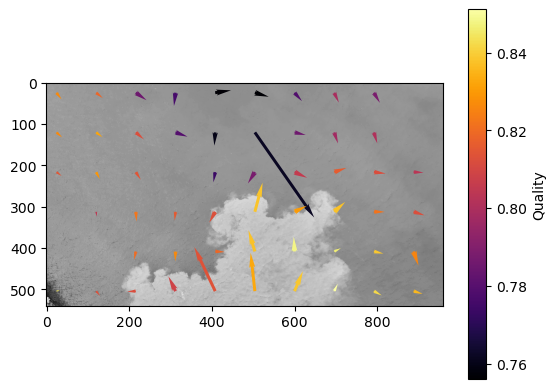

In [19]:
# median filtering

q_deviation = 0.015
q_threshold = 0.7

ux_masked_med, uy_masked_med = median_filter_iwave(ux, uy, q, dq = q_deviation, qth = q_threshold)

ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

quiv = ax.quiver(
    xi, yi, ux_masked_med, -uy_masked_med,
    q,                          
    angles="xy", scale=3, headwidth=2, linewidth=2,
    cmap="inferno"              
)

cbar = plt.colorbar(quiv, ax=ax)
cbar.set_label("Quality")

ax.set_aspect("equal")
plt.show()